# Emre - Disease Prediction (KNN vs Random Forest)

In this notebook I did:
- EDA (proper checks + plots)
- KNN model
- Random Forest model
- evaluation and short interpretation

Dataset notes:
- symptom features are binary (`0/1`)
- target is `prognosis` (text labels)


## 1) Imports and setup
I save all images and summaries into `notebooks/Emre` so everything for this task stays in one folder.


In [6]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')


## 2) Load train/test data
This works whether notebook is run from project root or from `notebooks/`.


In [7]:
DATA_DIR = Path('../../data/raw')
OUTPUT_DIR = Path('.')

FIG_DIR = OUTPUT_DIR / 'figures'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(DATA_DIR / 'Training.csv')
test_df = pd.read_csv(DATA_DIR / 'Testing.csv')

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
print('Target classes:', train_df['prognosis'].nunique())
print('DATA_DIR:', DATA_DIR.resolve())
print('OUTPUT_DIR:', OUTPUT_DIR.resolve())

train_df.head()


Train shape: (4920, 133)
Test shape : (42, 133)
Target classes: 41
DATA_DIR: /Users/emreozkan/Desktop/DSI_Certificates/Disease_Prediction_With_ML/data/raw
OUTPUT_DIR: /Users/emreozkan/Desktop/DSI_Certificates/Disease_Prediction_With_ML/notebooks/Emre


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


## 3) EDA - data quality + quick stats


In [8]:
X_train = train_df.drop(columns=['prognosis'])
y_train = train_df['prognosis']
X_test = test_df.drop(columns=['prognosis'])
y_test = test_df['prognosis']

missing_train = int(train_df.isna().sum().sum())
missing_test = int(test_df.isna().sum().sum())
feature_unique_values = [int(v) for v in sorted(pd.unique(X_train.values.ravel()))]
class_counts = y_train.value_counts().sort_values(ascending=False)
symptom_count_per_record = X_train.sum(axis=1)
feature_prevalence = X_train.mean().sort_values(ascending=False)

eda_summary = {
    'missing_train_total': missing_train,
    'missing_test_total': missing_test,
    'feature_unique_values': feature_unique_values,
    'n_classes': int(class_counts.shape[0]),
    'class_min_count': int(class_counts.min()),
    'class_max_count': int(class_counts.max()),
    'class_mean_count': float(class_counts.mean()),
    'symptoms_per_record_min': int(symptom_count_per_record.min()),
    'symptoms_per_record_max': int(symptom_count_per_record.max()),
    'symptoms_per_record_mean': float(symptom_count_per_record.mean()),
    'symptoms_per_record_median': float(symptom_count_per_record.median()),
    'feature_prevalence_mean': float(feature_prevalence.mean()),
    'feature_prevalence_max': float(feature_prevalence.max()),
}

(OUTPUT_DIR / 'eda_summary.json').write_text(json.dumps(eda_summary, indent=2))
print(json.dumps(eda_summary, indent=2))
pd.DataFrame([eda_summary])


{
  "missing_train_total": 0,
  "missing_test_total": 0,
  "feature_unique_values": [
    0,
    1
  ],
  "n_classes": 41,
  "class_min_count": 120,
  "class_max_count": 120,
  "class_mean_count": 120.0,
  "symptoms_per_record_min": 3,
  "symptoms_per_record_max": 17,
  "symptoms_per_record_mean": 7.4487804878048784,
  "symptoms_per_record_median": 6.0,
  "feature_prevalence_mean": 0.05643015521064302,
  "feature_prevalence_max": 0.3926829268292683
}


,missing_train_total,missing_test_total,feature_unique_values,n_classes,class_min_count,class_max_count,class_mean_count,symptoms_per_record_min,symptoms_per_record_max,symptoms_per_record_mean,symptoms_per_record_median,feature_prevalence_mean,feature_prevalence_max
0,0,0,"[0, 1]",41,120,120,120.0,3,17,7.44878,6.0,0.05643,0.392683


## 4) EDA plots


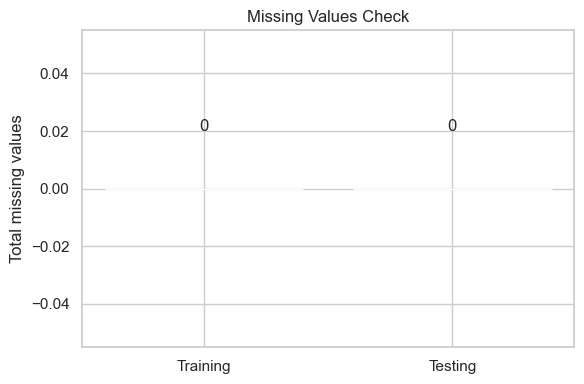

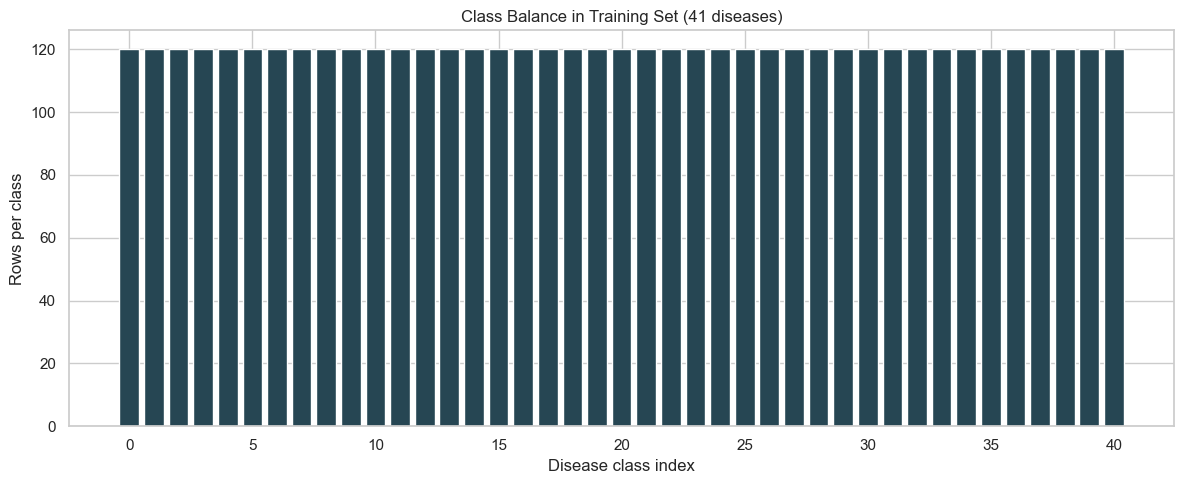

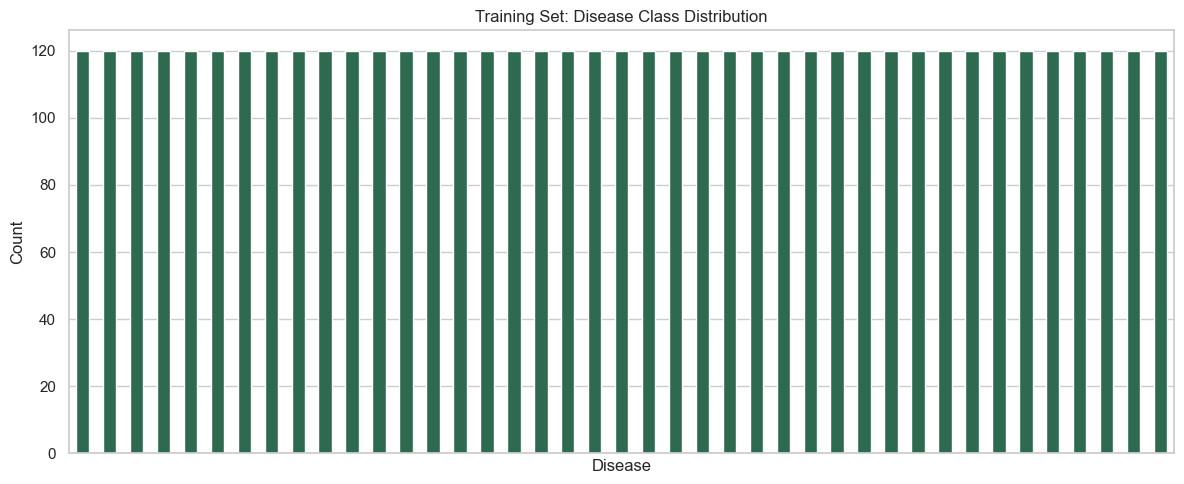

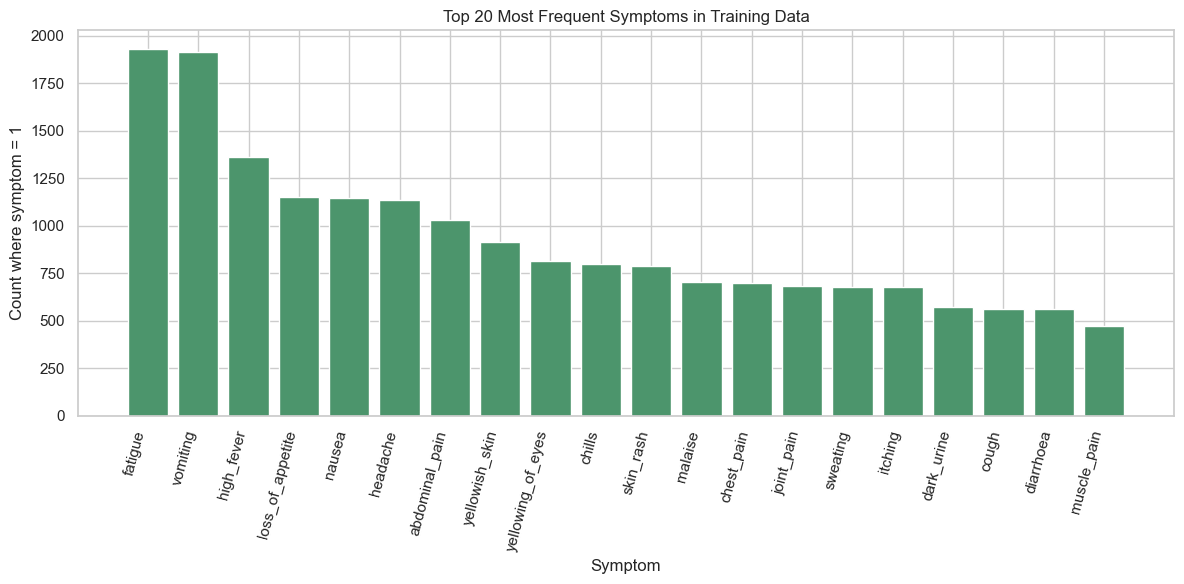

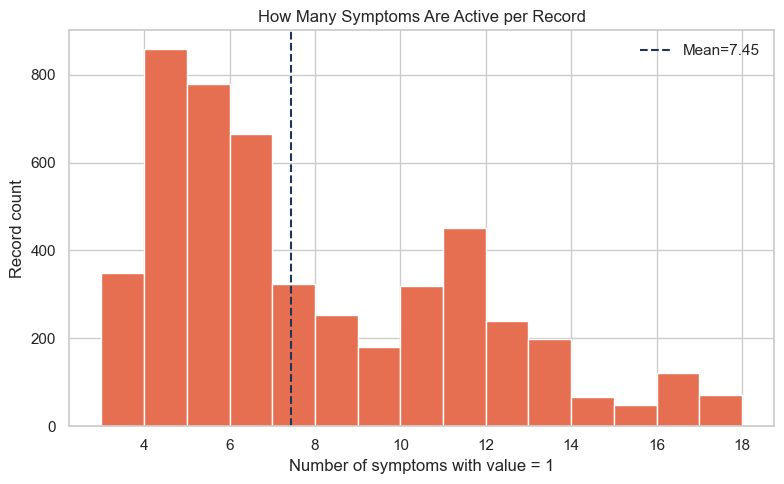

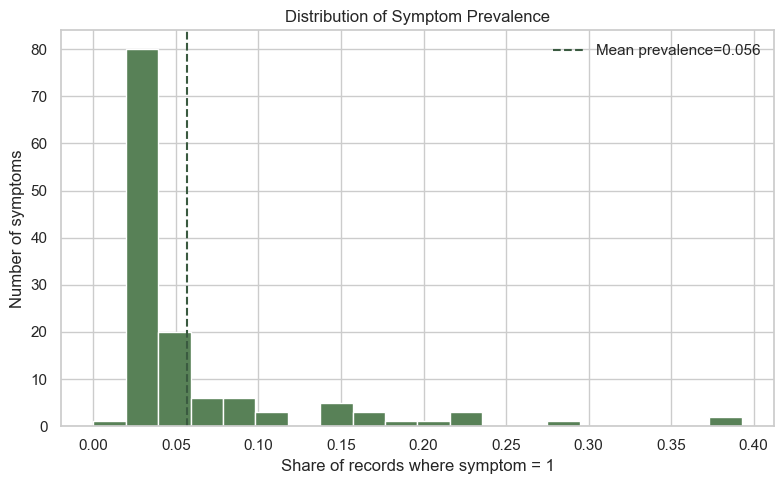

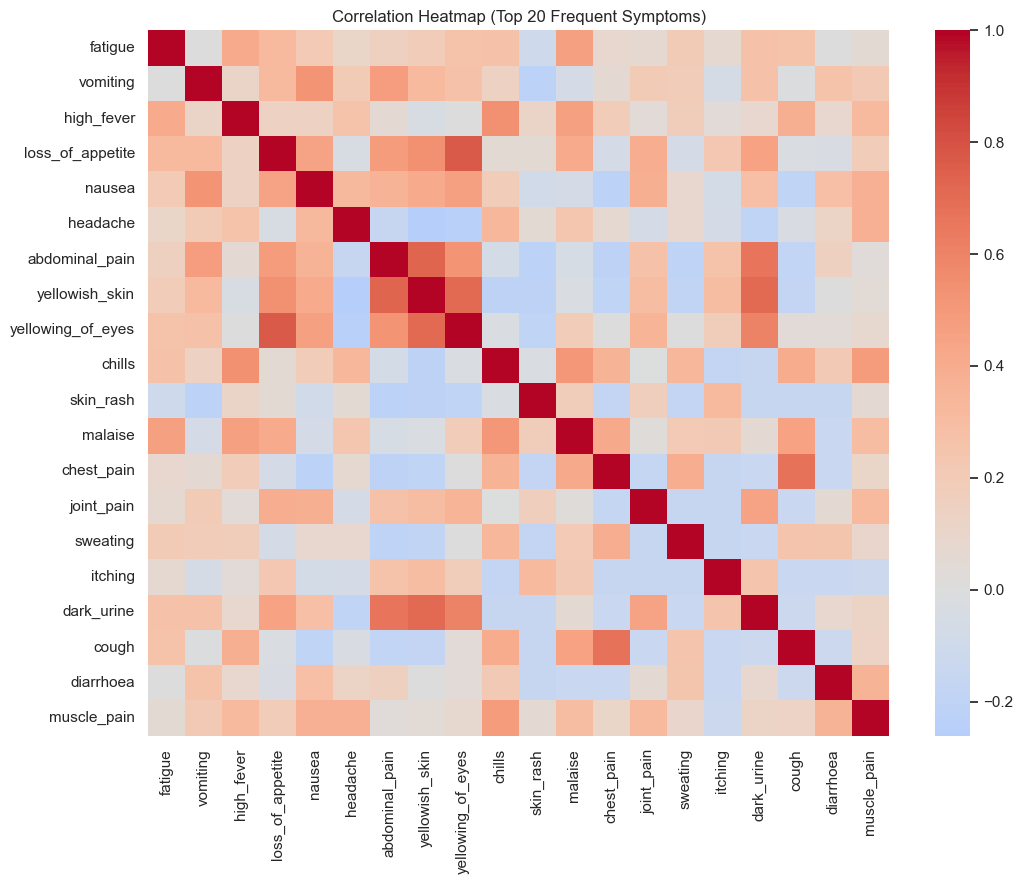

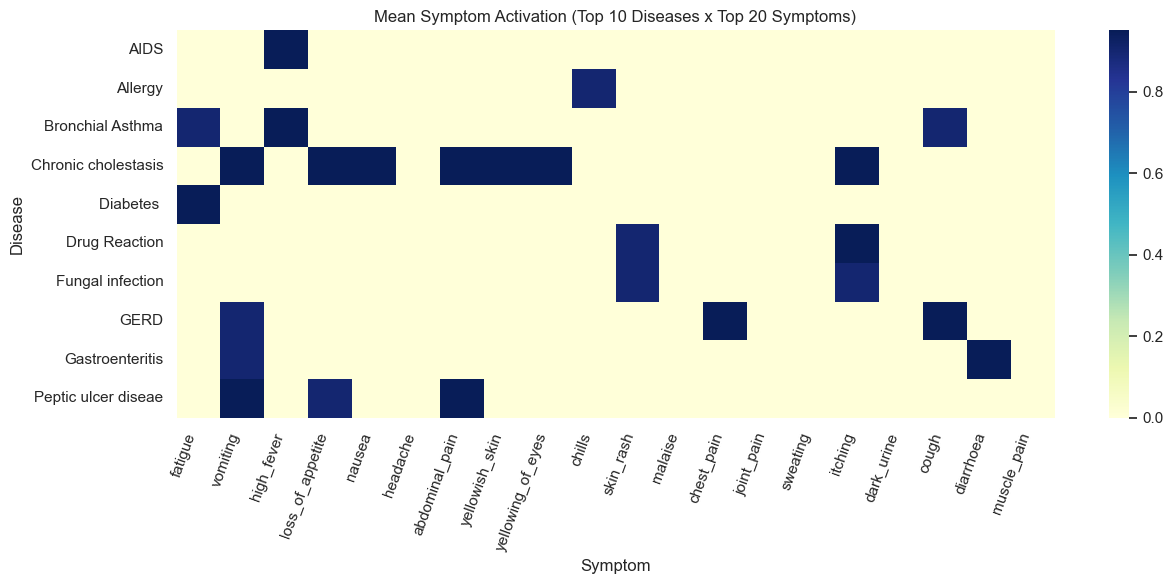

In [12]:
# Plot 1: missing values check
missing_summary = pd.DataFrame({
    'dataset': ['Training', 'Testing'],
    'missing_values': [missing_train, missing_test]
})
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(missing_summary['dataset'], missing_summary['missing_values'], color=['#2a9d8f', '#457b9d'])
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{int(bar.get_height())}", ha='center')
ax.set_title('Missing Values Check')
ax.set_ylabel('Total missing values')
fig.tight_layout()
fig.savefig(FIG_DIR / 'eda_missing_values.png', dpi=160)
plt.show()

# Plot 2: class balance
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(class_counts)), class_counts.values, color='#264653')
ax.set_title('Class Balance in Training Set (41 diseases)')
ax.set_xlabel('Disease class index')
ax.set_ylabel('Rows per class')
fig.tight_layout()
fig.savefig(FIG_DIR / 'eda_class_balance.png', dpi=160)
plt.show()


# Extra base data plots used in README
fig, ax = plt.subplots(figsize=(12, 5))
class_counts.plot(kind='bar', color='#2d6a4f', ax=ax)
ax.set_title('Training Set: Disease Class Distribution')
ax.set_xlabel('Disease')
ax.set_ylabel('Count')
ax.set_xticks([])
fig.tight_layout()
fig.savefig(FIG_DIR / 'class_distribution.png', dpi=160)
plt.show()

symptom_freq = X_train.sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(symptom_freq.head(20).index, symptom_freq.head(20).values, color='#4c956c')
ax.set_title('Top 20 Most Frequent Symptoms in Training Data')
ax.set_xlabel('Symptom')
ax.set_ylabel('Count where symptom = 1')
plt.xticks(rotation=75, ha='right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'top_symptoms.png', dpi=160)
plt.show()

# Plot 3: active symptom count distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(symptom_count_per_record, bins=range(int(symptom_count_per_record.min()), int(symptom_count_per_record.max()) + 2), color='#e76f51', edgecolor='white')
ax.axvline(symptom_count_per_record.mean(), color='#1d3557', linestyle='--', label=f"Mean={symptom_count_per_record.mean():.2f}")
ax.set_title('How Many Symptoms Are Active per Record')
ax.set_xlabel('Number of symptoms with value = 1')
ax.set_ylabel('Record count')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'eda_symptoms_per_record_distribution.png', dpi=160)
plt.show()

# Plot 4: feature prevalence histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(feature_prevalence.values, bins=20, color='#588157', edgecolor='white')
ax.axvline(feature_prevalence.mean(), color='#3a5a40', linestyle='--', label=f"Mean prevalence={feature_prevalence.mean():.3f}")
ax.set_title('Distribution of Symptom Prevalence')
ax.set_xlabel('Share of records where symptom = 1')
ax.set_ylabel('Number of symptoms')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'eda_feature_prevalence_histogram.png', dpi=160)
plt.show()

# Plot 5: top 20 symptom correlation heatmap
top20_symptoms = X_train.sum().sort_values(ascending=False).head(20).index
corr = X_train[top20_symptoms].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap (Top 20 Frequent Symptoms)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'eda_top20_symptom_correlation.png', dpi=160)
plt.show()

# Plot 6: disease x symptom heatmap (compact view)
selected_diseases = class_counts.index[:10]
selected_symptoms = X_train.sum().sort_values(ascending=False).head(20).index
heat_df = train_df[train_df['prognosis'].isin(selected_diseases)].groupby('prognosis')[selected_symptoms].mean()
fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(heat_df, cmap='YlGnBu', ax=ax)
ax.set_title('Mean Symptom Activation (Top 10 Diseases x Top 20 Symptoms)')
ax.set_xlabel('Symptom')
ax.set_ylabel('Disease')
plt.xticks(rotation=70, ha='right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'eda_disease_symptom_heatmap.png', dpi=160)
plt.show()


### EDA takeaways (short)
- No missing values in train/test.
- Features are truly binary (`0/1`).
- Classes are perfectly balanced (120 rows each disease in training set).
- Symptom activations are sparse: average prevalence is low (~5.6%).
- Each record has around 7 active symptoms on average.

This all confirms why models can get really high accuracy on this dataset.


## 5) Encode target labels
Only `prognosis` needs encoding.


In [13]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

print('Encoded classes:', len(label_encoder.classes_))


Encoded classes: 41


## 6) KNN tuning (k search with CV)
I test odd `k` values and pick the best 5-fold CV score.


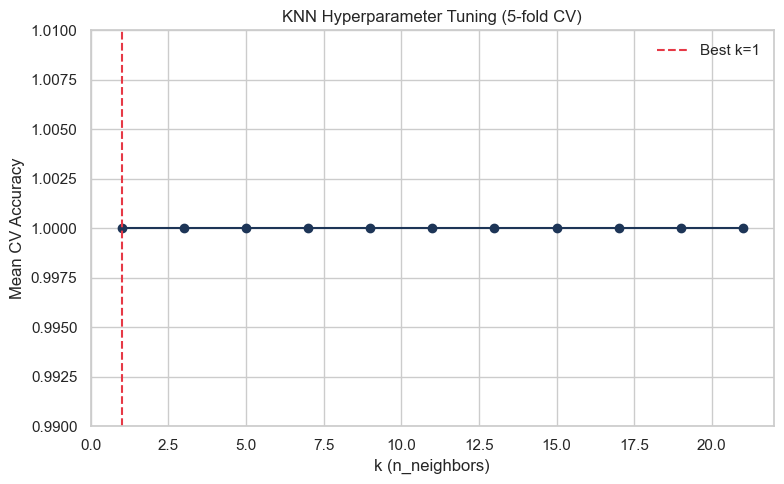

Best k: 1
Best CV Accuracy: 1.0000


In [11]:
k_values = list(range(1, 22, 2))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(model, X_train, y_train_enc, cv=cv, scoring='accuracy', n_jobs=1).mean()
    cv_scores.append(score)

best_idx = int(np.argmax(cv_scores))
best_k = k_values[best_idx]
best_k_cv_acc = cv_scores[best_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, cv_scores, marker='o', color='#1d3557')
ax.axvline(best_k, color='#e63946', linestyle='--', label=f'Best k={best_k}')
ax.set_title('KNN Hyperparameter Tuning (5-fold CV)')
ax.set_xlabel('k (n_neighbors)')
ax.set_ylabel('Mean CV Accuracy')
ax.set_ylim(min(cv_scores) - 0.01, 1.01)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'knn_cv_curve.png', dpi=160)
plt.show()

print(f'Best k: {best_k}')
print(f'Best CV Accuracy: {best_k_cv_acc:.4f}')


## 7) Standalone KNN model

Train KNN by itself first, then evaluate.


In [14]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train_enc)

knn_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test_enc, knn_pred)
knn_report = classification_report(y_test_enc, knn_pred, output_dict=True, zero_division=0)

print(f'KNN Test Accuracy: {knn_accuracy:.4f}')
print(f'KNN Macro F1     : {knn_report["macro avg"]["f1-score"]:.4f}')


KNN Test Accuracy: 1.0000
KNN Macro F1     : 1.0000


## 8) Standalone Random Forest model

Train Random Forest separately and evaluate it on the same test set.


In [15]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=1,
)
rf_model.fit(X_train, y_train_enc)

rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test_enc, rf_pred)
rf_report = classification_report(y_test_enc, rf_pred, output_dict=True, zero_division=0)

print(f'RF  Test Accuracy: {rf_accuracy:.4f}')
print(f'RF  Macro F1     : {rf_report["macro avg"]["f1-score"]:.4f}')


RF  Test Accuracy: 0.9762
RF  Macro F1     : 0.9837


## 9) KNN vs Random Forest comparison

Now compare both standalone models side-by-side.


In [17]:
comparison_df = pd.DataFrame({
    'Model': ['KNN', 'Random Forest'],
    'Accuracy': [knn_accuracy, rf_accuracy],
    'Macro F1': [knn_report['macro avg']['f1-score'], rf_report['macro avg']['f1-score']],
})
comparison_df

,Model,Accuracy,Macro F1
0,KNN,1.00000,1.00000
1,Random Forest,0.97619,0.98374


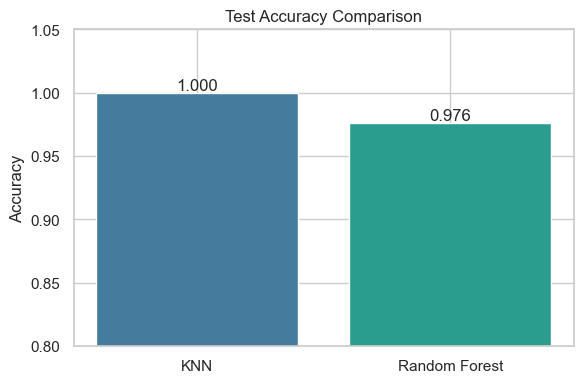

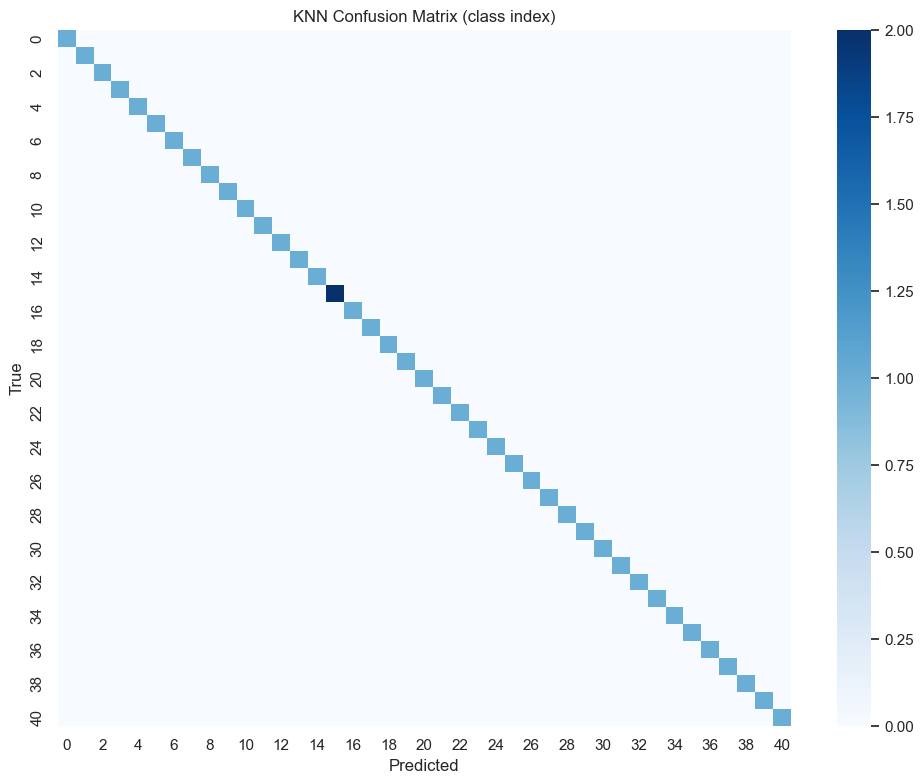

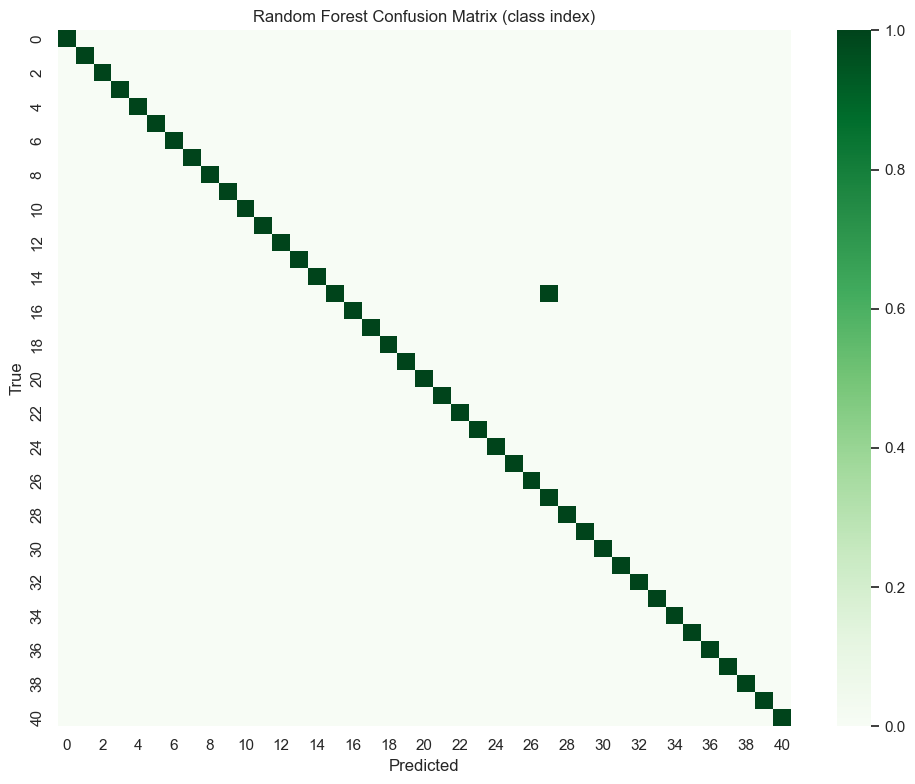

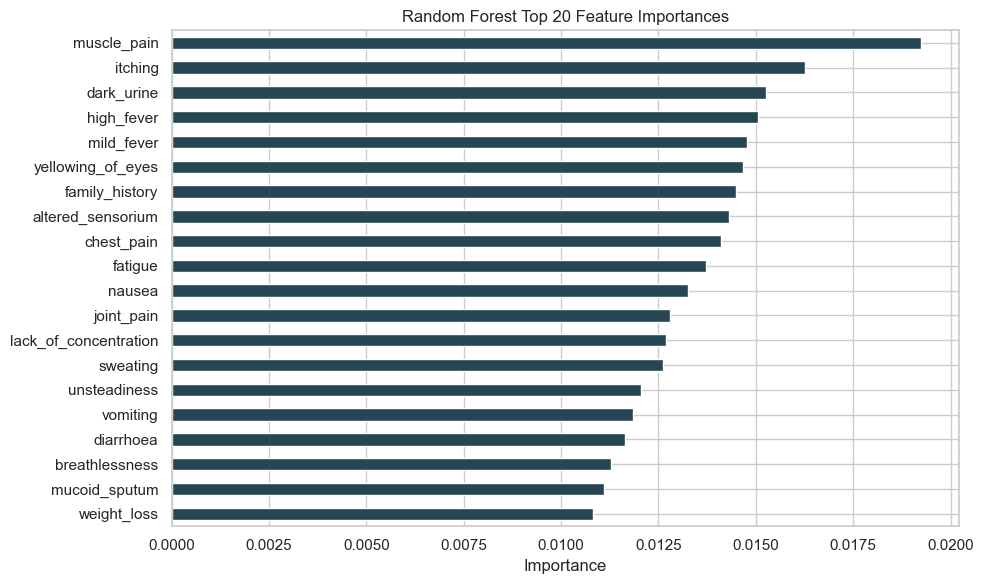

muscle_pain          0.019249
itching              0.016266
dark_urine           0.015259
high_fever           0.015046
mild_fever           0.014777
yellowing_of_eyes    0.014665
family_history       0.014499
altered_sensorium    0.014302
chest_pain           0.014103
fatigue              0.013721
dtype: float64

In [18]:
# Plot: model accuracy comparison
fig, ax = plt.subplots(figsize=(6, 4))
models = ['KNN', 'Random Forest']
accs = [knn_accuracy, rf_accuracy]
bars = ax.bar(models, accs, color=['#457b9d', '#2a9d8f'])
for bar, value in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.002, f'{value:.3f}', ha='center')
ax.set_title('Test Accuracy Comparison')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.8, 1.05)
fig.tight_layout()
fig.savefig(FIG_DIR / 'model_accuracy_comparison.png', dpi=160)
plt.show()

# Plot: confusion matrices
labels = list(range(len(label_encoder.classes_)))
cm_knn = confusion_matrix(y_test_enc, knn_pred, labels=labels)
cm_rf = confusion_matrix(y_test_enc, rf_pred, labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_knn, cmap='Blues', cbar=True, ax=ax)
ax.set_title('KNN Confusion Matrix (class index)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
fig.tight_layout()
fig.savefig(FIG_DIR / 'knn_confusion_matrix.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_rf, cmap='Greens', cbar=True, ax=ax)
ax.set_title('Random Forest Confusion Matrix (class index)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
fig.tight_layout()
fig.savefig(FIG_DIR / 'rf_confusion_matrix.png', dpi=160)
plt.show()

# RF feature importance
rf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
rf_importance.head(20).sort_values().plot(kind='barh', color='#264653', ax=ax)
ax.set_title('Random Forest Top 20 Feature Importances')
ax.set_xlabel('Importance')
fig.tight_layout()
fig.savefig(FIG_DIR / 'rf_top_features.png', dpi=160)
plt.show()

metrics_summary = {
    'train_shape': list(train_df.shape),
    'test_shape': list(test_df.shape),
    'n_features': int(X_train.shape[1]),
    'n_classes': int(len(label_encoder.classes_)),
    'best_k': int(best_k),
    'best_k_cv_accuracy': float(best_k_cv_acc),
    'knn_test_accuracy': float(knn_accuracy),
    'rf_test_accuracy': float(rf_accuracy),
    'knn_macro_f1': float(knn_report['macro avg']['f1-score']),
    'rf_macro_f1': float(rf_report['macro avg']['f1-score']),
}
(OUTPUT_DIR / 'metrics_summary.json').write_text(json.dumps(metrics_summary, indent=2))

rf_importance.head(10)


## 10) Why this accuracy happens

Short and real answer:
- this dataset is generated and very clean
- binary features + balanced classes + repeated patterns
- train and test are very close in structure

So KNN can basically memorize patterns (`k=1`) and Random Forest also performs really high.


## 11) What can be improved

If I keep building this:
1. get real/noisy clinical data to test generalization
2. tune RF deeper (`max_depth`, `min_samples_leaf`, etc.)
3. add top-k metrics (top-3 diagnosis)
4. check calibration and confidence reliability
5. compare with a few more baselines for context
